# Análise Exploratória - Detecção de Fraude em Cartão de Crédito

**Disciplina:** Inteligência Artificial – 7ºJ SI - Noite (Prof. Dr. Leandro Zerbinatti)

**Integrantes do grupo:** Eduarda | Sara | Anna

**Autora deste arquivo:** Sara

**Síntese do conteúdo:** Este notebook contém a parte da análise exploratória: histogramas das variáveis `Amount` e `Time`, e matriz de correlação entre as variáveis do dataset.

**Histórico de alterações:**

| Data | Autor | Descrição |
|------|-------|-----------|
| 2026-09-13 | Sara | Criação do notebook: histogramas de Amount/Time e matriz de correlação |


## 1 - Importação das bibliotecas

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 2 - Carregamento do dataset

Dataset público: [Credit Card Fraud Detection - Kaggle (mlg-ulb/creditcardfraud)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

> Obs.: baixe o arquivo `creditcard.csv` do Kaggle e coloque na mesma pasta deste notebook (ou ajuste o caminho abaixo).

In [44]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Histograma da variável `Amount`

Representa o valor monetário de cada transação. É importante observar a assimetria da distribuição (muitas transações de baixo valor e poucas de valor alto).

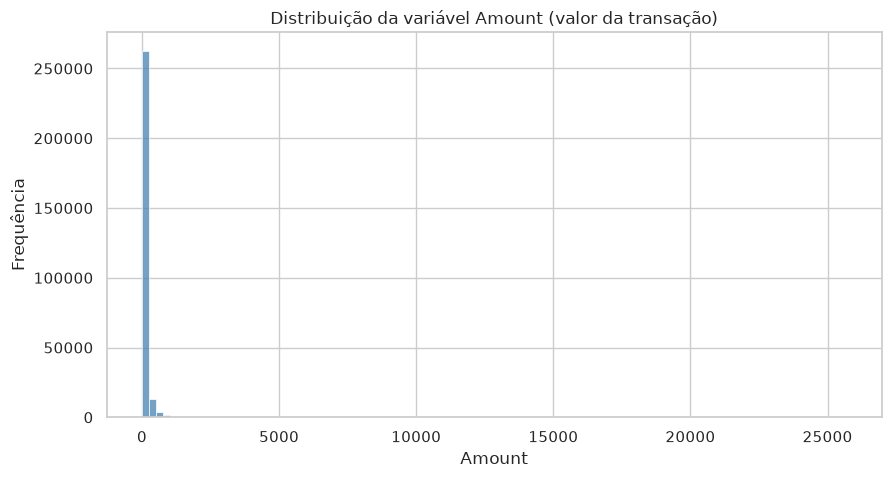

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=100, kde=False, color='steelblue')
plt.title('Distribuição da variável Amount (valor da transação)')
plt.xlabel('Amount')
plt.ylabel('Frequência')
plt.show()

print(df['Amount'].describe())

Como a distribuição costuma ser bastante concentrada em valores baixos, vale plotar também em escala logarítmica para visualizar melhor a cauda da distribuição:

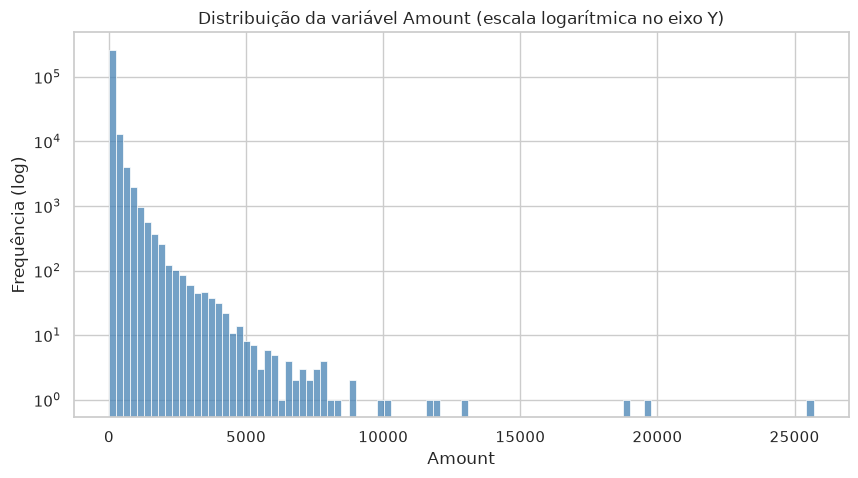

In [46]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=100, color='steelblue')
plt.yscale('log')
plt.title('Distribuição da variável Amount (escala logarítmica no eixo Y)')
plt.xlabel('Amount')
plt.ylabel('Frequência (log)')
plt.show()

## 4. Histograma da variável `Time`

Representa o tempo, em segundos, decorrido entre cada transação e a primeira transação do dataset (o dataset cobre um período de 2 dias).

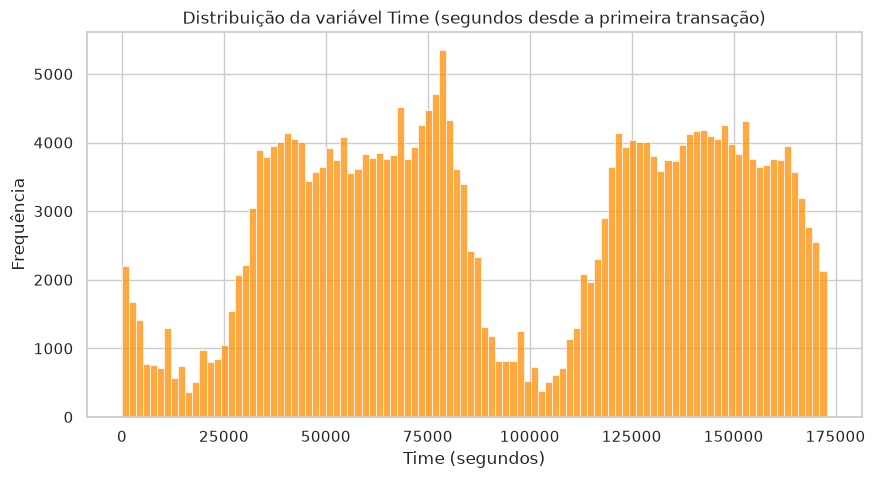

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Time'], bins=100, color='darkorange')
plt.title('Distribuição da variável Time (segundos desde a primeira transação)')
plt.xlabel('Time (segundos)')
plt.ylabel('Frequência')
plt.show()

print(df['Time'].describe())

É possível notar dois picos distintos ao longo do tempo, que correspondem aproximadamente aos dois dias cobertos pelo dataset, com maior volume de transações durante o período diurno de cada dia.

## 5. Matriz de Correlação

Como as variáveis V1 a V28 já passaram por uma transformação PCA, espera-se baixa correlação entre elas (o PCA gera componentes ortogonais/não correlacionados). O objetivo aqui é confirmar isso e observar se `Amount`, `Time` ou `Class` apresentam alguma correlação relevante com as demais variáveis.

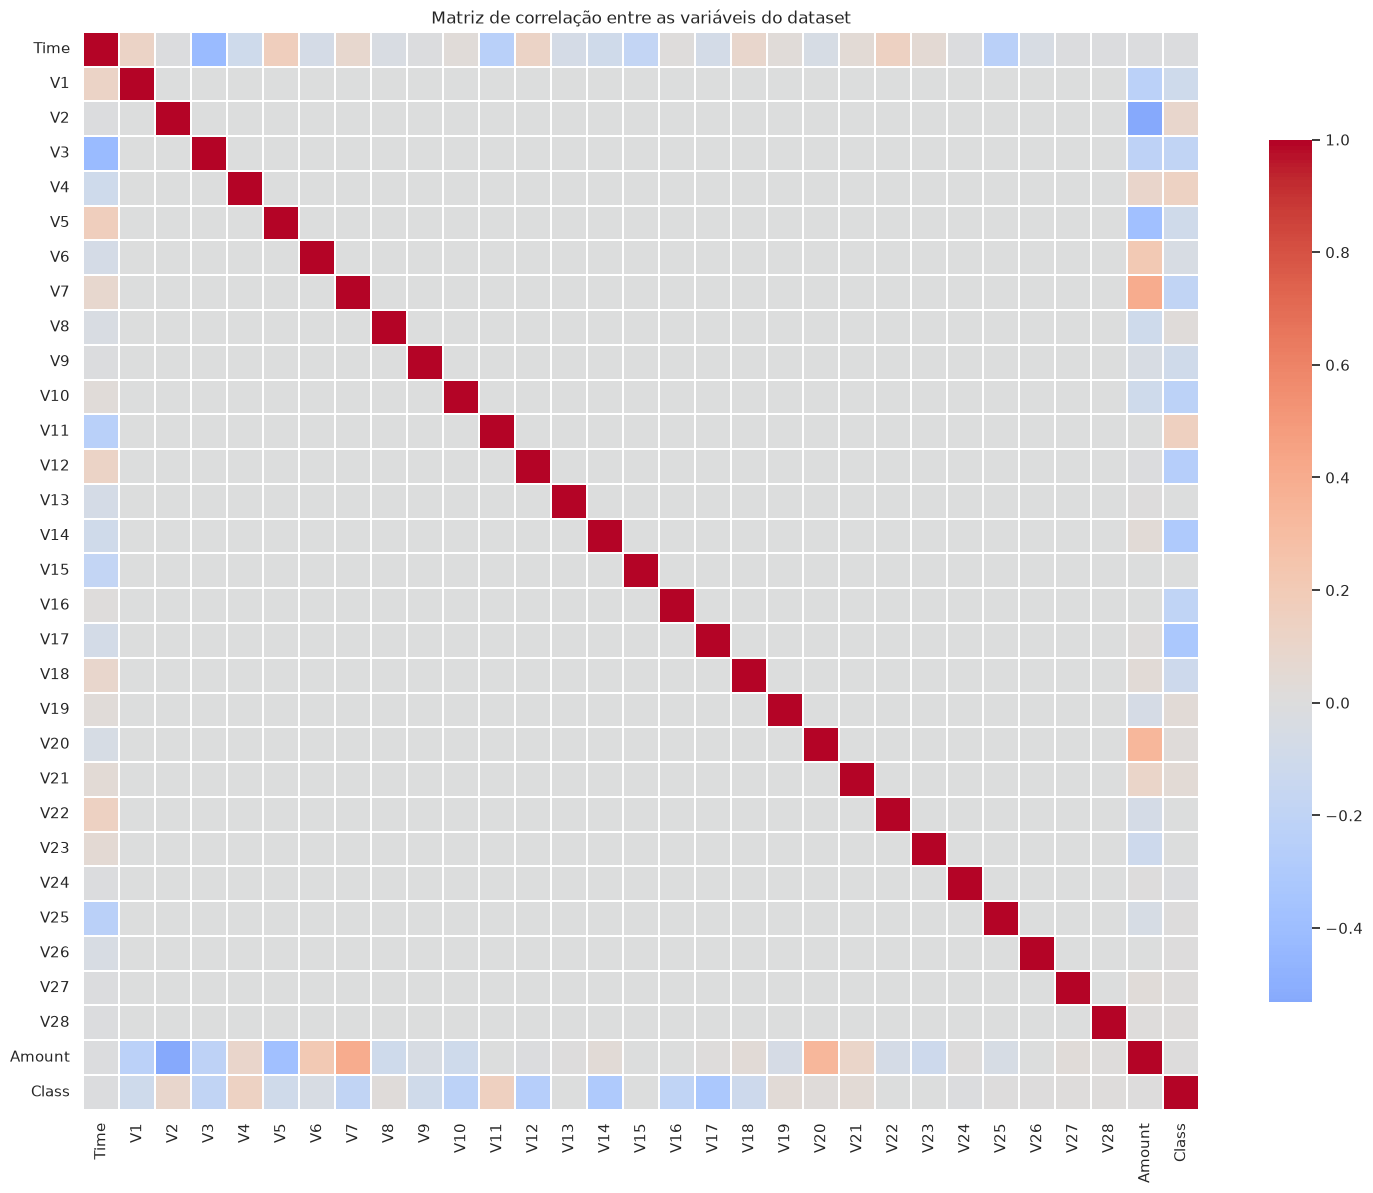

In [48]:
corr = df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação entre as variáveis do dataset')
plt.show()

Para facilitar a leitura, vale destacar especificamente a correlação de cada variável com a variável-alvo `Class`:

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


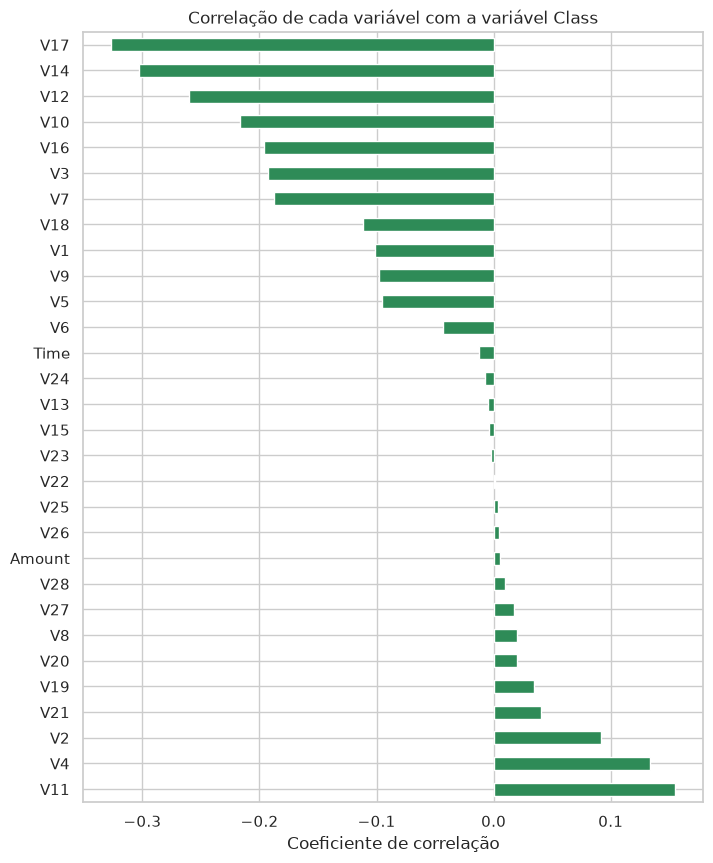

In [49]:
corr_class = corr['Class'].sort_values(ascending=False)
print(corr_class)

plt.figure(figsize=(8, 10))
corr_class.drop('Class').plot(kind='barh', color='seagreen')
plt.title('Correlação de cada variável com a variável Class')
plt.xlabel('Coeficiente de correlação')
plt.show()

### Observações preliminares

- As variáveis V1-V28, por serem componentes de PCA, apresentam correlação praticamente nula entre si, como esperado.
- Algumas variáveis (ex.: V17, V14, V12, V10 negativamente, e V11, V4 positivamente — os valores exatos serão observados na execução) tendem a apresentar correlação mais forte com `Class`, sinalizando maior poder discriminante para o modelo.
- `Amount` e `Time` apresentam correlação fraca com `Class`, mas ainda assim serão normalizadas/tratadas na etapa de preparação dos dados (parte da Anna), já que estão em escalas muito diferentes das variáveis V1-V28.